In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

# Root dataset prepared
BASE_DIR = Path("../")  # ajuste si besoin
PREP_ROOT = BASE_DIR / "data" / "prepared" / "pannuke"

print("PREP_ROOT =", PREP_ROOT)
assert PREP_ROOT.exists(), f"Prepared root not found: {PREP_ROOT}"


PREP_ROOT = ..\data\prepared\pannuke


In [2]:
#Check structure du dataset (train/val/test)

def check_split_structure(root: Path, split: str):
    p = root / split
    for sub in ["images", "masks", "types", "instances"]:
        assert (p / sub).exists(), f"Missing {p/sub}"
    imgs = sorted((p/"images").glob("img_*.npy"))
    msks = sorted((p/"masks").glob("mask_*.npy"))
    typs = sorted((p/"types").glob("type_*.npy"))
    inst = sorted((p/"instances").glob("instance_class_*.npy"))
    print(f"[{split}] images={len(imgs)} masks={len(msks)} types={len(typs)} inst_maps={len(inst)}")
    assert len(imgs) > 0, f"No images in {p/'images'}"
    return imgs

for split in ["train","val","test"]:
    if (PREP_ROOT/split).exists():
        check_split_structure(PREP_ROOT, split)


[train] images=2620 masks=2620 types=2620 inst_maps=2620
[val] images=2465 masks=2465 types=2465 inst_maps=2465
[test] images=2656 masks=2656 types=2656 inst_maps=2656


In [3]:
# Sanity check d’un échantillon (dtype, shapes, ranges, mapping)

def sanity_one_sample(root: Path, split: str = "val", idx: int = 0):
    p = root / split
    img_files = sorted((p/"images").glob("img_*.npy"))
    assert len(img_files) > idx, "idx out of range"

    img_p = img_files[idx]
    msk_p = p/"masks"/img_p.name.replace("img_","mask_")
    typ_p = p/"types"/img_p.name.replace("img_","type_")
    icm_p = p/"instances"/img_p.name.replace("img_","instance_class_")

    img = np.load(img_p)
    msk = np.load(msk_p)
    typ = np.load(typ_p)
    icm = np.load(icm_p)

    print("FILE:", img_p.name)
    print("img:", img.shape, img.dtype, "min/max:", float(img.min()), float(img.max()))
    print("msk:", msk.shape, msk.dtype, "max_inst:", int(msk.max()), "unique:", len(np.unique(msk)))
    print("typ:", typ.shape, typ.dtype, "unique(sample):", np.unique(typ)[:15])
    print("icm:", icm.shape, icm.dtype, "map_len:", len(icm), "max(icm):", int(icm.max()) if len(icm)>0 else None)

    # Hard asserts
    assert img.ndim == 3 and img.shape[2] == 3
    assert img.dtype == np.float32, "img should be float32"
    assert img.min() >= -1e-3 and img.max() <= 1.0 + 1e-3, "img not in [0,1]"
    assert msk.shape == img.shape[:2]
    assert typ.shape == msk.shape
    assert len(icm) == int(msk.max()) + 1, "instance_class map length must be max_inst+1"
    # types should not be all zeros (unless truly no nuclei)
    if msk.max() > 0:
        assert typ.max() > 0, "type map seems empty (all zeros) while instances exist"
    # instance->class: if instances exist, at least some should have class > 0
    if msk.max() > 0:
        assert icm.max() > 0, "instance_class map has no class labels (all zeros?)"

    return img, msk, typ, icm, img_p.name

img, gt_inst, type_map, inst_class_map, name = sanity_one_sample(PREP_ROOT, "val", 0)


FILE: img_002621.npy
img: (256, 256, 3) float32 min/max: 0.12156862765550613 1.0
msk: (256, 256) uint16 max_inst: 8 unique: 9
typ: (256, 256) uint8 unique(sample): [0 1 3]
icm: (9,) uint8 map_len: 9 max(icm): 3


In [4]:
# Vérifier le CSV morpho (si déjà calculé)

morph_csv = PREP_ROOT / "pannuke_morphology_with_classes.csv"
print("Morph CSV:", morph_csv)

if morph_csv.exists():
    df = pd.read_csv(morph_csv)
    print("rows:", len(df), "cols:", list(df.columns)[:10], "...")
    print("class_id top:", df["class_id"].value_counts().head(10))
    print("morph_class:", df["morph_class"].value_counts())
    assert len(df) > 0, "Morphology CSV is empty"
    assert df["class_id"].max() > 0, "class_id looks empty"
else:
    print("Morphology CSV not found yet. Run compute_morphology_pannuke.py first.")


Morph CSV: ..\data\prepared\pannuke\pannuke_morphology_with_classes.csv
rows: 162995 cols: ['split', 'image', 'instance_id', 'class_id', 'area', 'perimeter', 'eccentricity', 'solidity', 'circularity', 'bbox_aspect'] ...
class_id top: class_id
1    63618
3    46452
2    28555
5    21667
4     2703
Name: count, dtype: int64
morph_class: morph_class
elongated    68942
other        45189
round        37462
irregular    11402
Name: count, dtype: int64


In [5]:
# Métriques pixel-level (Dice/IoU) + matching instance-level (F1)
def dice_iou_pixel(pred_bin: np.ndarray, gt_bin: np.ndarray):
    pred = pred_bin.astype(bool)
    gt = gt_bin.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    pred_sum = pred.sum()
    gt_sum = gt.sum()
    dice = (2*inter) / (pred_sum + gt_sum + 1e-8)
    iou = inter / (union + 1e-8)
    return float(dice), float(iou)

def instance_iou_matrix(pred_inst: np.ndarray, gt_inst: np.ndarray):
    # Build IoU matrix between instances (excluding background 0)
    pred_ids = np.unique(pred_inst)
    gt_ids = np.unique(gt_inst)
    pred_ids = pred_ids[pred_ids != 0]
    gt_ids = gt_ids[gt_ids != 0]

    M = np.zeros((len(gt_ids), len(pred_ids)), dtype=np.float32)
    if len(gt_ids)==0 or len(pred_ids)==0:
        return M, gt_ids, pred_ids

    # Precompute masks
    pred_masks = {pid: (pred_inst == pid) for pid in pred_ids}
    gt_masks = {gid: (gt_inst == gid) for gid in gt_ids}

    for i, gid in enumerate(gt_ids):
        g = gt_masks[gid]
        gsum = g.sum()
        for j, pid in enumerate(pred_ids):
            p = pred_masks[pid]
            inter = np.logical_and(g, p).sum()
            if inter == 0:
                continue
            union = gsum + p.sum() - inter
            M[i, j] = inter / (union + 1e-8)
    return M, gt_ids, pred_ids

def f1_instance(pred_inst: np.ndarray, gt_inst: np.ndarray, iou_thr: float = 0.5):
    M, gt_ids, pred_ids = instance_iou_matrix(pred_inst, gt_inst)
    if M.size == 0:
        # if both empty => perfect
        if (len(gt_ids)==0) and (len(pred_ids)==0):
            return 1.0, 0, 0, 0
        # else => all FN or FP
        TP = 0
        FP = len(pred_ids)
        FN = len(gt_ids)
        f1 = 0.0
        return f1, TP, FP, FN

    # Greedy matching by descending IoU
    pairs = []
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if M[i,j] >= iou_thr:
                pairs.append((float(M[i,j]), i, j))
    pairs.sort(reverse=True, key=lambda x: x[0])

    matched_gt = set()
    matched_pred = set()
    TP = 0

    for iou, i, j in pairs:
        if i in matched_gt or j in matched_pred:
            continue
        matched_gt.add(i)
        matched_pred.add(j)
        TP += 1

    FP = M.shape[1] - TP
    FN = M.shape[0] - TP
    f1 = (2*TP) / (2*TP + FP + FN + 1e-8)
    return float(f1), int(TP), int(FP), int(FN)


In [6]:
# Tests “prédiction nulle” et “prédiction parfaite” (doivent passer)
H, W = gt_inst.shape

pred_zero = np.zeros((H,W), dtype=np.int32)
pred_perfect = gt_inst.astype(np.int32)

# Pixel
dice0, iou0 = dice_iou_pixel(pred_zero>0, gt_inst>0)
dice1, iou1 = dice_iou_pixel(pred_perfect>0, gt_inst>0)

# Instance
f10, TP0, FP0, FN0 = f1_instance(pred_zero, gt_inst, iou_thr=0.5)
f11, TP1, FP1, FN1 = f1_instance(pred_perfect, gt_inst, iou_thr=0.5)

print("ZERO  | dice:", dice0, "iou:", iou0, "F1inst:", f10, "TP/FP/FN:", TP0, FP0, FN0)
print("PERF  | dice:", dice1, "iou:", iou1, "F1inst:", f11, "TP/FP/FN:", TP1, FP1, FN1)

assert abs(dice0 - 0.0) < 1e-6 and abs(iou0 - 0.0) < 1e-6 and abs(f10 - 0.0) < 1e-6
assert abs(dice1 - 1.0) < 1e-6 and abs(iou1 - 1.0) < 1e-6 and abs(f11 - 1.0) < 1e-6
print("[OK] Evaluator sanity checks passed.")


ZERO  | dice: 0.0 iou: 0.0 F1inst: 0.0 TP/FP/FN: 0 0 8
PERF  | dice: 0.9999999999993665 iou: 0.999999999998733 F1inst: 0.999999999375 TP/FP/FN: 8 0 0
[OK] Evaluator sanity checks passed.


In [8]:
# U-Net post-processing (prob → instances) via Watershed
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.morphology import remove_small_objects, h_maxima

def unet_prob_to_instances(prob, thr=0.5, min_size=20, h=1.5):
    bin_mask = prob > thr
    bin_mask = remove_small_objects(bin_mask, min_size=min_size)

    if bin_mask.sum() == 0:
        return np.zeros_like(prob, dtype=np.int32)

    dist = ndi.distance_transform_edt(bin_mask)

    # h-maxima: limite le nombre de seeds (plus h est grand, moins il y a de seeds)
    seeds = h_maxima(dist, h=h)
    seeds &= bin_mask

    markers, _ = ndi.label(seeds)
    if markers.max() == 0:
        markers, _ = ndi.label(bin_mask)

    labels = watershed(-dist, markers, mask=bin_mask)
    return labels.astype(np.int32)

# Test on GT-bin "as if it was perfect prob"
prob_fake = (gt_inst > 0).astype(np.float32)
ws_inst = unet_prob_to_instances(prob_fake, thr=0.5, min_size=20, h=1.5)

print("GT instances:", int(gt_inst.max()), "WS instances from perfect bin:", int(ws_inst.max()))
f1_ws, TP, FP, FN = f1_instance(ws_inst, gt_inst, iou_thr=0.5)
print("F1inst(ws on GT-bin):", f1_ws, "TP/FP/FN:", TP, FP, FN)


GT instances: 8 WS instances from perfect bin: 10
F1inst(ws on GT-bin): 0.8888888883950616 TP/FP/FN: 8 2 0


In [9]:
# Test “data loader” rapide (CPU) sans Lightning
import torch
from torch.utils.data import DataLoader

# Adapte cet import à ton projet
from src.pannuke_dataset import PannukePreparedDataset

ds = PannukePreparedDataset(PREP_ROOT, split="val", transform=None, return_image_name=True)
dl = DataLoader(ds, batch_size=2, shuffle=False, num_workers=0)

batch = next(iter(dl))
img_t, mask_t, types_t, names = batch

print("img_t:", img_t.shape, img_t.dtype)
print("mask_t:", mask_t.shape, mask_t.dtype, "max:", int(mask_t.max()))
print("types_t:", types_t.shape, types_t.dtype, "max:", int(types_t.max()))
print("names:", names[:2])


img_t: torch.Size([2, 3, 256, 256]) torch.float32
mask_t: torch.Size([2, 256, 256]) torch.int64 max: 10
types_t: torch.Size([2, 256, 256]) torch.int64 max: 3
names: ('img_002621.npy', 'img_002622.npy')


In [11]:
# Smoke run U-Net forward (1 batch) + conversion prob → instances + métriques
import torch
import torch.nn.functional as F

from models.unet import UNet  # adapte si besoin

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

model = UNet(in_channels=3, out_channels=1, base_ch=64).to(device)
model.eval()

# prendre 1 sample (pas besoin du dataloader)
img_t, gt_inst_t, types_t, name = ds[0]
img = img_t.unsqueeze(0).to(device)  # (1,3,H,W)
gt_inst_np = gt_inst_t.numpy().astype(np.int32)

with torch.no_grad():
    logits = model(img)  # (1,1,H,W)
    prob = torch.sigmoid(logits)[0,0].detach().cpu().numpy()

pred_inst = unet_prob_to_instances(prob, thr=0.5, min_size=20, h=1.5)

dice, iou = dice_iou_pixel(pred_inst>0, gt_inst_np>0)
f1, TP, FP, FN = f1_instance(pred_inst, gt_inst_np, iou_thr=0.5)

print("sample:", name)
print("pixel dice/iou:", dice, iou)
print("inst F1@0.5:", f1, "TP/FP/FN:", TP, FP, FN)
print("nb_pred/nb_gt:", int(pred_inst.max()), int(gt_inst_np.max()))


device: cuda
sample: img_002621.npy
pixel dice/iou: 0.21498318103198805 0.12043762207029413
inst F1@0.5: 0.0 TP/FP/FN: 0 1 8
nb_pred/nb_gt: 1 8


In [12]:
# Smoke run StarDist decode (sans entraîner) juste pour vérifier que decode ne plante pas
from models.stardist import StarDist, stardist_decode

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

R = 32
st = StarDist(input_ch=3, n_rays=R, base_ch=64).to(device)
st.eval()

img_t, gt_inst_t, types_t, name = ds[0]
img = img_t.unsqueeze(0).to(device)
gt_inst_np = gt_inst_t.numpy().astype(np.int32)

with torch.no_grad():
    out = st(img)[0].detach().cpu().numpy()  # (1+R,H,W)
prob = 1/(1+np.exp(-out[0]))                 # sigmoid on logits
dist = out[1:]                               # already positive if you used softplus in model

pred_inst = stardist_decode(
    prob_map=prob.astype(np.float32),
    dist_map=dist.astype(np.float32),
    prob_thr=0.5,
    nms_iou_thr=0.3,
    use_local_maxima=True,
    local_max_footprint=3,
    max_candidates=2000,
    min_area=10
)

dice, iou = dice_iou_pixel(pred_inst>0, gt_inst_np>0)
f1, TP, FP, FN = f1_instance(pred_inst, gt_inst_np, iou_thr=0.5)

print("sample:", name)
print("pixel dice/iou:", dice, iou)
print("inst F1@0.5:", f1, "TP/FP/FN:", TP, FP, FN)
print("nb_pred/nb_gt:", int(pred_inst.max()), int(gt_inst_np.max()))


device: cuda
sample: img_002621.npy
pixel dice/iou: 0.0 0.0
inst F1@0.5: 0.0 TP/FP/FN: 0 0 8
nb_pred/nb_gt: 0 8


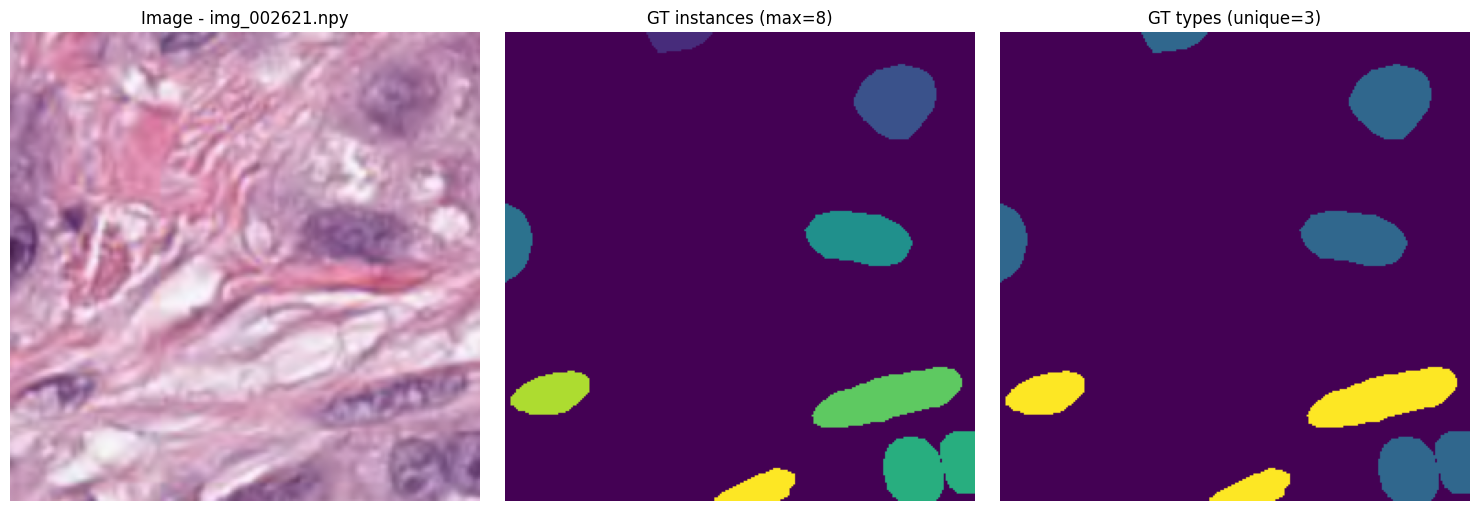

In [13]:
#Afficher image + GT instances + GT types
import matplotlib.pyplot as plt

def show_sample(prep_root: Path, split="val", idx=0):
    p = prep_root / split
    img_files = sorted((p/"images").glob("img_*.npy"))
    img_p = img_files[idx]

    msk_p = p/"masks"/img_p.name.replace("img_","mask_")
    typ_p = p/"types"/img_p.name.replace("img_","type_")

    img = np.load(img_p)
    inst = np.load(msk_p).astype(np.int32)
    typ  = np.load(typ_p).astype(np.int32)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img)
    ax[0].set_title(f"Image - {img_p.name}")
    ax[0].axis("off")

    ax[1].imshow(inst)
    ax[1].set_title(f"GT instances (max={inst.max()})")
    ax[1].axis("off")

    ax[2].imshow(typ)
    ax[2].set_title(f"GT types (unique={len(np.unique(typ))})")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()

show_sample(PREP_ROOT, "val", 0)


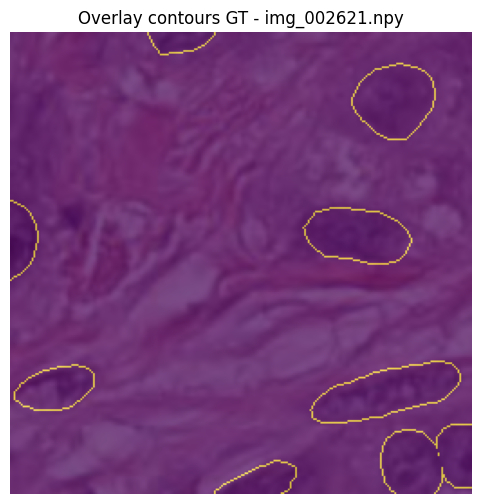

In [14]:
# overlay contour GT sur cellules

from skimage.segmentation import find_boundaries

def show_overlay_contours(prep_root: Path, split="val", idx=0):
    p = prep_root / split
    img_p = sorted((p/"images").glob("img_*.npy"))[idx]
    msk_p = p/"masks"/img_p.name.replace("img_","mask_")

    img = np.load(img_p)
    inst = np.load(msk_p).astype(np.int32)

    boundaries = find_boundaries(inst, mode="outer")

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img)
    ax.imshow(boundaries, alpha=0.7)  # contours par dessus
    ax.set_title(f"Overlay contours GT - {img_p.name}")
    ax.axis("off")
    plt.show()

show_overlay_contours(PREP_ROOT, "val", 0)


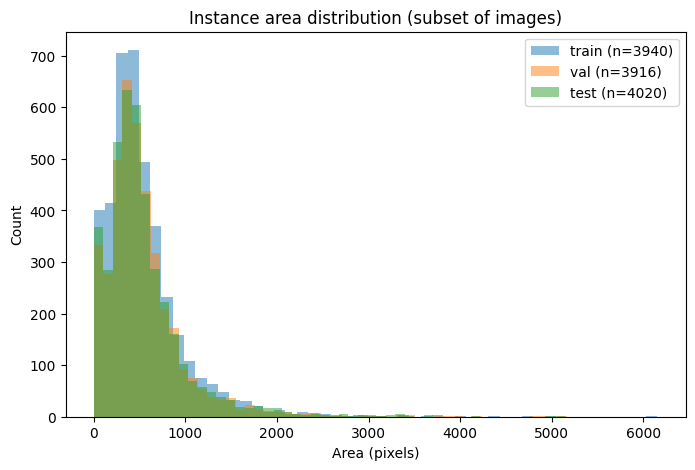

In [15]:
#Distribution des tailles d’instances (train vs val vs test)
import numpy as np
import matplotlib.pyplot as plt

def instance_area_hist(prep_root: Path, split="train", max_images=200):
    p = prep_root / split
    img_files = sorted((p/"images").glob("img_*.npy"))[:max_images]
    areas = []

    for img_p in img_files:
        msk_p = p/"masks"/img_p.name.replace("img_","mask_")
        inst = np.load(msk_p).astype(np.int32)
        ids = np.unique(inst)
        ids = ids[ids != 0]
        for pid in ids:
            areas.append(int((inst == pid).sum()))

    return np.array(areas, dtype=np.int32)

splits = [s for s in ["train","val","test"] if (PREP_ROOT/s).exists()]
areas_by_split = {s: instance_area_hist(PREP_ROOT, s, max_images=200) for s in splits}

plt.figure(figsize=(8,5))
for s, a in areas_by_split.items():
    if len(a) == 0:
        continue
    plt.hist(a, bins=50, alpha=0.5, label=f"{s} (n={len(a)})")
plt.title("Instance area distribution (subset of images)")
plt.xlabel("Area (pixels)")
plt.ylabel("Count")
plt.legend()
plt.show()


In [16]:
# Répartition des classes (types) dans le dataset

from collections import Counter

def type_distribution(prep_root: Path, split="train", max_images=200):
    p = prep_root / split
    img_files = sorted((p/"images").glob("img_*.npy"))[:max_images]
    ctr = Counter()

    for img_p in img_files:
        typ_p = p/"types"/img_p.name.replace("img_","type_")
        typ = np.load(typ_p).astype(np.int32)
        vals, counts = np.unique(typ, return_counts=True)
        for v, c in zip(vals, counts):
            ctr[int(v)] += int(c)

    return ctr

splits = [s for s in ["train","val","test"] if (PREP_ROOT/s).exists()]
for s in splits:
    ctr = type_distribution(PREP_ROOT, s, max_images=200)
    total = sum(ctr.values())
    # ignore 0 background for display
    keys = sorted(k for k in ctr.keys() if k != 0)
    print(f"\n[{s}] type pixel distribution (excluding bg):")
    for k in keys[:15]:
        print(f"  class {k}: {ctr[k]/max(1,total):.4f}")



[train] type pixel distribution (excluding bg):
  class 1: 0.0519
  class 2: 0.0107
  class 3: 0.0365
  class 4: 0.0000
  class 5: 0.0660

[val] type pixel distribution (excluding bg):
  class 1: 0.0437
  class 2: 0.0086
  class 3: 0.0345
  class 4: 0.0001
  class 5: 0.0748

[test] type pixel distribution (excluding bg):
  class 1: 0.0416
  class 2: 0.0075
  class 3: 0.0313
  class 5: 0.0863


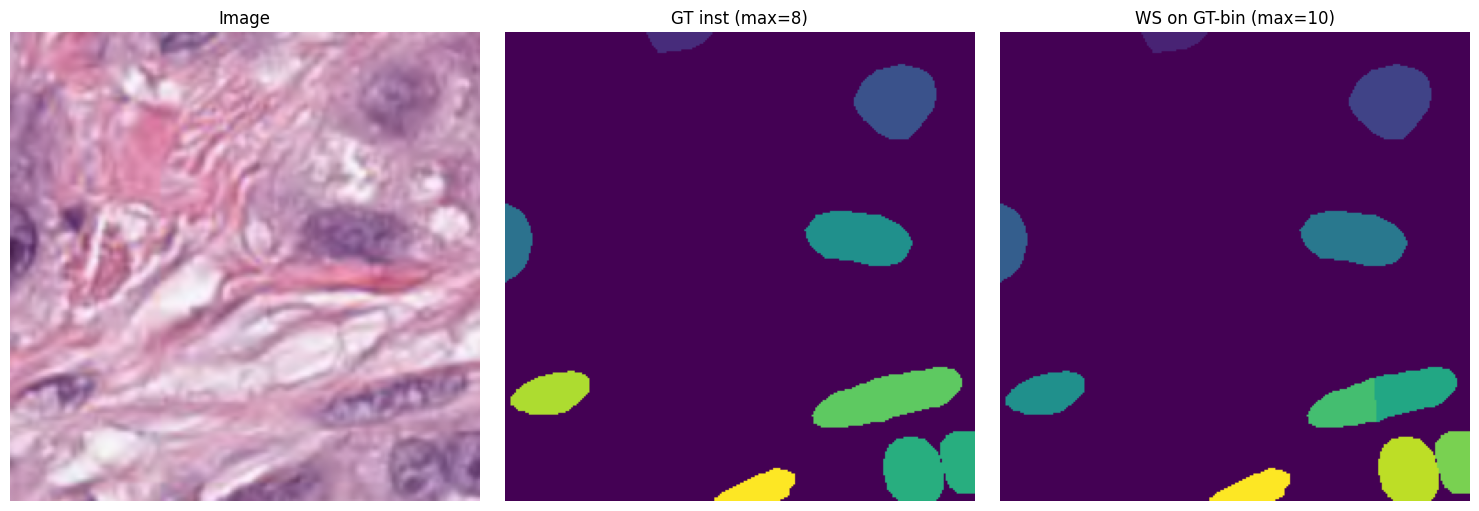

In [18]:
# Visualiser post-proc U-Net sur un sample (prob fake + watershed)
import matplotlib.pyplot as plt

def show_watershed_on_gt(prep_root: Path, split="val", idx=0):
    p = prep_root / split
    img_p = sorted((p/"images").glob("img_*.npy"))[idx]
    msk_p = p/"masks"/img_p.name.replace("img_","mask_")

    img = np.load(img_p)
    gt = np.load(msk_p).astype(np.int32)

    prob_fake = (gt > 0).astype(np.float32)
    ws = unet_prob_to_instances(prob_fake, thr=0.5, min_size=20, h=1.5)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img); ax[0].set_title("Image"); ax[0].axis("off")
    ax[1].imshow(gt);  ax[1].set_title(f"GT inst (max={gt.max()})"); ax[1].axis("off")
    ax[2].imshow(ws);  ax[2].set_title(f"WS on GT-bin (max={ws.max()})"); ax[2].axis("off")
    plt.tight_layout()
    plt.show()

show_watershed_on_gt(PREP_ROOT, "val", 0)


# Smoke train unet

In [22]:
import torch
import numpy as np
from pathlib import Path
import pytorch_lightning as pl
from pytorch_lightning.callbacks import Callback
from torch.utils.data import DataLoader

# --- adapte ces imports à ton projet ---
from src.pannuke_dataset import PannukePreparedDataset
from models.unet import UNet
from src.losses import bce_dice_loss

# === paramètres ===
PREP_ROOT = Path("../data/prepared/pannuke")
BATCH_SIZE = 4
NUM_WORKERS = 2
MAX_TRAIN_BATCHES = 50
MAX_VAL_SAMPLES = 10

# === ton post-proc watershed (la version h-maxima) ===
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.morphology import remove_small_objects, h_maxima

def unet_prob_to_instances(prob, thr=0.5, min_size=20, h=1.5):
    bin_mask = prob > thr
    bin_mask = remove_small_objects(bin_mask, min_size=min_size)
    if bin_mask.sum() == 0:
        return np.zeros_like(prob, dtype=np.int32)
    dist = ndi.distance_transform_edt(bin_mask)
    seeds = h_maxima(dist, h=h)
    seeds &= bin_mask
    markers, _ = ndi.label(seeds)
    if markers.max() == 0:
        markers, _ = ndi.label(bin_mask)
    labels = watershed(-dist, markers, mask=bin_mask)
    return labels.astype(np.int32)

# === métriques ===
def dice_iou_pixel(pred_bin: np.ndarray, gt_bin: np.ndarray):
    pred = pred_bin.astype(bool); gt = gt_bin.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    dice = (2*inter) / (pred.sum() + gt.sum() + 1e-8)
    iou  = inter / (union + 1e-8)
    return float(dice), float(iou)

def instance_iou_matrix(pred_inst: np.ndarray, gt_inst: np.ndarray):
    pred_ids = np.unique(pred_inst); pred_ids = pred_ids[pred_ids != 0]
    gt_ids   = np.unique(gt_inst);   gt_ids   = gt_ids[gt_ids != 0]
    M = np.zeros((len(gt_ids), len(pred_ids)), dtype=np.float32)
    if len(gt_ids)==0 or len(pred_ids)==0:
        return M
    pred_masks = {pid:(pred_inst==pid) for pid in pred_ids}
    gt_masks   = {gid:(gt_inst==gid) for gid in gt_ids}
    for i,gid in enumerate(gt_ids):
        g = gt_masks[gid]; gsum = g.sum()
        for j,pid in enumerate(pred_ids):
            p = pred_masks[pid]
            inter = np.logical_and(g,p).sum()
            if inter==0: continue
            union = gsum + p.sum() - inter
            M[i,j] = inter/(union+1e-8)
    return M

def f1_instance(pred_inst: np.ndarray, gt_inst: np.ndarray, iou_thr=0.5):
    M = instance_iou_matrix(pred_inst, gt_inst)
    if M.size == 0:
        # both empty -> perfect, else zero
        if pred_inst.max()==0 and gt_inst.max()==0:
            return 1.0, 0, 0, 0
        return 0.0, 0, int(pred_inst.max()>0), int(gt_inst.max()>0)

    pairs = [(float(M[i,j]), i, j) for i in range(M.shape[0]) for j in range(M.shape[1]) if M[i,j]>=iou_thr]
    pairs.sort(reverse=True, key=lambda x:x[0])

    matched_gt=set(); matched_pred=set(); TP=0
    for iou,i,j in pairs:
        if i in matched_gt or j in matched_pred:
            continue
        matched_gt.add(i); matched_pred.add(j); TP+=1
    FP = M.shape[1]-TP
    FN = M.shape[0]-TP
    f1 = (2*TP)/(2*TP+FP+FN+1e-8)
    return float(f1), int(TP), int(FP), int(FN)

# === Dataset: transform binaire pour U-Net ===
def unet_simple_transform(img_t, mask_t, types_t=None):
    mask_bin = (mask_t > 0).float().unsqueeze(0)  # (1,H,W)
    return img_t, mask_bin, types_t

train_ds = PannukePreparedDataset(PREP_ROOT, split="train", transform=unet_simple_transform)
val_ds   = PannukePreparedDataset(PREP_ROOT, split="val",   transform=unet_simple_transform, return_image_name=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

# === Lightning ===
class UNetLit(pl.LightningModule):
    def __init__(self, lr=1e-4, wd=1e-4, base_ch=64):
        super().__init__()
        self.save_hyperparameters()
        self.net = UNet(in_channels=3, out_channels=1, base_ch=base_ch)

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, batch_idx):
        img, mask_bin, _ = batch
        logits = self(img)
        loss = bce_dice_loss(logits, mask_bin)
        self.log("train_loss", loss, prog_bar=True, on_step=True, on_epoch=False, batch_size=img.size(0))
        return loss

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)

class SmokeEvalUNet(Callback):
    def __init__(self, val_loader, max_samples=10, thr=0.5, min_size=20, h=1.5):
        super().__init__()
        self.val_loader = val_loader
        self.max_samples = max_samples
        self.thr = thr
        self.min_size = min_size
        self.h = h

    def on_train_epoch_end(self, trainer, pl_module):
        pl_module.eval()
        device = pl_module.device

        dices=[]; ious=[]; f1s=[]; n_pred=[]; n_gt=[]
        with torch.no_grad():
            for k, (img_t, mask_bin_t, _, name) in enumerate(self.val_loader):
                if k >= self.max_samples: break

                img = img_t.to(device)
                # GT instances from original mask file (reload)
                # name is like 'img_000123.npy'
                msk_p = PREP_ROOT/"val"/"masks"/name[0].replace("img_","mask_")
                gt_inst = np.load(msk_p).astype(np.int32)

                prob = torch.sigmoid(pl_module(img))[0,0].detach().cpu().numpy()
                pred_inst = unet_prob_to_instances(prob, thr=self.thr, min_size=self.min_size, h=self.h)

                d, i = dice_iou_pixel(pred_inst>0, gt_inst>0)
                f1, TP, FP, FN = f1_instance(pred_inst, gt_inst, iou_thr=0.5)

                dices.append(d); ious.append(i); f1s.append(f1)
                n_pred.append(int(pred_inst.max())); n_gt.append(int(gt_inst.max()))

        print(f"[SMOKE UNET] val@{self.max_samples} "
              f"Dice={np.mean(dices):.3f} IoU={np.mean(ious):.3f} F1inst={np.mean(f1s):.3f} "
              f"nb_pred={int(np.mean(n_pred))} nb_gt={int(np.mean(n_gt))}")

        pl_module.train()

model = UNetLit(lr=1e-4, wd=1e-4, base_ch=64)

trainer = pl.Trainer(
    max_epochs=1,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    limit_train_batches=MAX_TRAIN_BATCHES,
    enable_progress_bar=True,
    log_every_n_steps=10,
    callbacks=[SmokeEvalUNet(val_loader, max_samples=MAX_VAL_SAMPLES, thr=0.5, min_size=20, h=1.5)],
)

trainer.fit(model, train_dataloaders=train_loader)


AttributeError: partially initialized module 'pytorch_lightning' has no attribute 'accelerators' (most likely due to a circular import)